In [1]:
import pandas as pd 
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
conn=sqlite3.connect("/Users/shyamchauhan/Desktop/home/codes/project/vendor_invoice_intelligence_portal/data/inventory.db")
tables=pd.read_sql_query("select name from sqlite_master where type='table'",conn)

In [3]:
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [4]:
for table in tables['name']:
    print("Table name : ",table)
    df=pd.read_sql_query(f"select * from {table} limit 5",conn)
    # display(df)

Table name :  purchases
Table name :  purchase_prices
Table name :  vendor_invoice
Table name :  begin_inventory
Table name :  end_inventory


In [5]:
vendor_df=pd.read_sql_query("select * from vendor_invoice",conn)
vendor_df.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


In [6]:
vendor_df[['Quantity','Freight','Dollars']].corr() # corr is used to find correlation coefficient
vendor_df.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


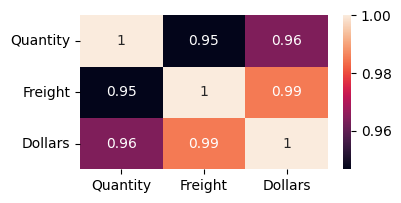

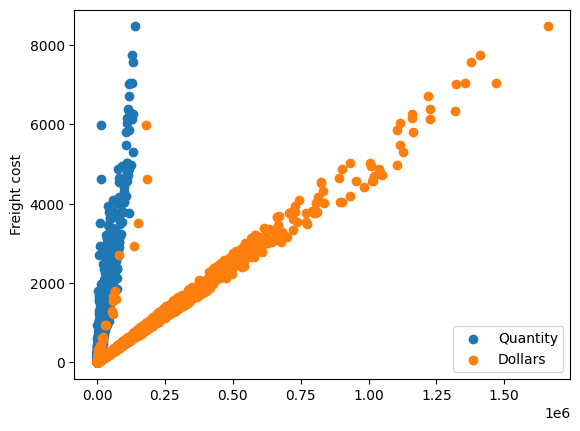

In [7]:
# relation between Quantity , Freight ,Dollars

plt.figure(figsize=(4,2))
sns.heatmap(vendor_df[['Quantity','Freight','Dollars']].corr(),annot=True)
plt.show()

plt.scatter(vendor_df['Quantity'],vendor_df['Freight'])
plt.scatter(vendor_df['Dollars'],vendor_df['Freight'])
plt.legend(['Quantity','Dollars'])
plt.ylabel('Freight cost')
plt.show()

In [8]:
vendor_df['freight_cost_per_unit']=vendor_df['Freight']/vendor_df['Quantity']
vendor_df

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval,freight_cost_per_unit
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None,0.578333
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None,0.571333
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None,0.922000
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None,0.290614
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None,0.221809
...,...,...,...,...,...,...,...,...,...,...,...
5538,9622,WEIN BAUER INC,2025-01-06,13626,2024-12-21,2025-02-10,90,1563.00,8.60,None,0.095556
5539,9625,WESTERN SPIRITS BEVERAGE CO,2025-01-10,13661,2024-12-23,2025-02-18,4617,37300.48,186.50,None,0.040394
5540,3664,WILLIAM GRANT & SONS INC,2025-01-02,13643,2024-12-22,2025-02-04,9848,202815.78,932.95,None,0.094735
5541,9815,WINE GROUP INC,2025-01-03,13602,2024-12-20,2025-02-08,24747,149007.56,819.54,None,0.033117


In [9]:
low_quantity=vendor_df['Quantity'].quantile(0.25)
high_quantity=vendor_df['Quantity'].quantile(0.75)

In [10]:
vendor_df.loc[vendor_df['Quantity']<low_quantity,'freight_cost_per_unit'].mean()

np.float64(0.09489854253138316)

In [11]:
vendor_df.loc[vendor_df['Quantity']>high_quantity,'freight_cost_per_unit'].mean() 
# mean is less implies that vendor pays less when orders high quantity

np.float64(0.049077654690759046)

In [12]:
X=vendor_df[['Dollars']]
Y=vendor_df['Freight']

In [13]:
vendor_df.describe().round()

,VendorNumber,PONumber,Quantity,Dollars,Freight,freight_cost_per_unit
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,20663.0,10889.0,6059.0,58073.0,296.0,0.0
std,34582.0,1601.0,14453.0,140234.0,714.0,0.0
min,2.0,8106.0,1.0,4.0,0.0,0.0
25%,3089.0,9504.0,83.0,968.0,5.0,0.0
50%,7240.0,10890.0,423.0,4765.0,25.0,0.0
75%,10754.0,12276.0,5100.0,44587.0,230.0,0.0
max,201359.0,13661.0,141660.0,1660436.0,8468.0,3.0


In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [17]:
model1=LinearRegression()
model1.fit(X_train,Y_train)

model2=DecisionTreeRegressor(max_depth=4 ,random_state=42)
model2.fit(X_train,Y_train)

model3=RandomForestRegressor(max_depth=4,random_state=42)
model3.fit(X_train,Y_train)

RandomForestRegressor(max_depth=4, random_state=42)

In [18]:
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_squared_error

def evaluate_model(model,X_test,Y_test,model_name):
    preds=model.predict(X_test)

    mae=mean_absolute_error(Y_test,preds)
    rmse = np.sqrt(mean_squared_error(Y_test, preds))
    # rmse=root_mean_squared_error(Y_test,preds,squared=False)
    r2=r2_score(Y_test,preds)*100

    print(f"\n{model_name} Performance : ")
    print(f"MAE : {mae:.2f}")
    print(f"RMSE : {rmse : .2f}")
    print(f"R_square : {r2:.2f}%")


In [19]:
evaluate_model(model1,X_test,Y_test,'Linear Regression')
evaluate_model(model2,X_test,Y_test,'Decision Tree Regression')
evaluate_model(model3,X_test,Y_test,'Random Forest Regression')


Linear Regression Performance : 
MAE : 24.11
RMSE :  124.72
R_square : 96.99%

Decision Tree Regression Performance : 
MAE : 38.12
RMSE :  138.25
R_square : 96.30%

Random Forest Regression Performance : 
MAE : 30.31
RMSE :  130.66
R_square : 96.69%


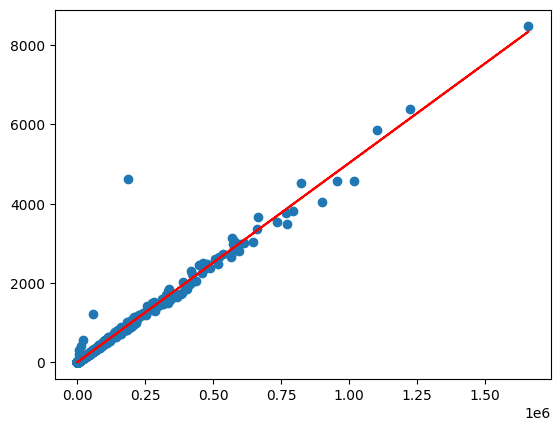

In [20]:
plt.scatter(X_test,Y_test)
plt.plot(X_test,model1.predict(X_test),color='red')

In [21]:
input_data={
    "Dollars":[18500,9000]
}
df=pd.DataFrame(input_data)

In [22]:
model1.predict(df)

array([97.78868161, 50.14455838])